# Step 2.1 Word Cloud for EPB Title Each Decade and All

In [1]:
#regular packages
import pandas as pd
import string
import os
#nlp packages
import nltk
import contractions
from nltk.corpus import stopwords
#nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *

In [2]:
#import nltk
#nltk.download('punkt')
#nltk.download('stopwords')
#import ssl

#try:
#    _create_unverified_https_context = ssl._create_unverified_context
#except AttributeError:
#    pass
#else:
#    ssl._create_default_https_context = _create_unverified_https_context#

#nltk.download()

# 0 Load Data
## 0.1 Individual decade

In [2]:
df70 = pd.read_csv('data_papers/1970s.csv')
df80 = pd.read_csv('data_papers/1980s.csv')
df90 = pd.read_csv('data_papers/1990s.csv')
df00 = pd.read_csv('data_papers/2000s.csv')
df10 = pd.read_csv('data_papers/2010s.csv')
df20 = pd.read_csv('data_papers/2020s.csv')

df_inpress = pd.read_csv('data_papers/inpress.csv')
df_data = pd.read_csv('data_papers/EPB_Data.csv')
df_fg = pd.read_csv('data_papers/EPB_FG.csv')

In [3]:
df_20 = pd.concat([df20, df_inpress, df_data, df_fg],  ignore_index=True)

In [4]:
directory_path = 'data_papers'
# List all files in the directory
files = os.listdir(directory_path)

# Filter out only CSV files
csv_files = [file for file in files if file.endswith('.csv')]

full_df = pd.DataFrame()
# Iterate through each CSV file and read it using pandas
for csv_file in csv_files:
    file_path = os.path.join(directory_path, csv_file)
    df = pd.read_csv(file_path)
    full_df = pd.concat([full_df, df])
    
    # Now you can work with the dataframe 'df'
    # For example, print the first few rows
    print(f"Contents of {csv_file}:")
print(len(full_df))
#print(full_df.head())    

Contents of 2020s.csv:
Contents of 2000s.csv:
Contents of 1990s.csv:
Contents of 2010s.csv:
Contents of inpress.csv:
Contents of EPB_FG.csv:
Contents of 1980s.csv:
Contents of EPB_Data.csv:
Contents of 1970s.csv:
2566


In [6]:
rows_with_nan = full_df[full_df["Title"] == 'nan']
rows_with_nan

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Programming Language,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body


## 1 Preprocessing: Cleaning Text 

### 1.1 Removing stop words along with other words
* remove the words shows uo more than 1000 time 
* remove meaingless words 

In [7]:
regular_stop_words = stopwords.words('english')

In [8]:
words_1k = ['urban', 'model', 'city', 'planning', 'study', 'data', 'spatial', 'use', 'area', 'based', 'paper', 'system']
words_other = ['result', 'ha', 'method', 'approach', 'using', 'different', 'new', 'used', 'level', 'research', 'two', 'information', 'wa', 'also', 'problem', 'effect'
                'type', 'show', 'case', 'impact', 'within', 'however', 'developed', 'application', 'high', 'context', 'relationship', 'may', 'potential', 'characteristic', 'finding', 'term', 'well', 'value', 'first', 'present', 'number', 'large', 'distribution', "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "finding", "built"]

additional_words = ['provide', 'technique', 'important', 'various', 'existing', 'way', 'applied', 'understanding', 'significant', 'need', 'future', 'many', 'size', 'found', 'across', 'higher', 'function', 'identify', 'presented']
                    #'time', 'issue', 'made', 'user', 'work', 'author', 'mean', 'map']#, 'article'

epb_stop_words = regular_stop_words + words_1k + words_other + additional_words

## 1.2 Full Test Cleaning

In [19]:
#from src.preprocessing import __general_preprocess__
from src.preprocessing import __remove_plurals__
from src.preprocessing import __remove_stopwords__
from src.preprocessing import __remove_punctuation__
from src.preprocessing import __get_word_freq__

In [14]:
def __general_preprocess__(text_col):
    # lowe cases
    text_col = text_col.apply(lambda x: ' '.join([w.lower() for w in x.split()]))
    # expand contractions
    text_col = text_col.apply(lambda x: ' '.join([contractions.fix(word) for word in x.split()]))
    # remove numbers
    text_col = text_col.apply(lambda x: ' '.join(re.sub("[^a-zA-Z]+", " ", x).split()))

    return text_col

In [15]:
full_df['Title'] = full_df['Title'].astype(str)
full_df['title_clean'] = __general_preprocess__(full_df['Title'])
full_df['title_clean'] = full_df['title_clean'].apply(lambda x: __remove_plurals__(x))
full_df['title_clean'] = __remove_stopwords__(full_df['title_clean'], epb_stop_words)
full_freq = __get_word_freq__(full_df['title_clean'])

In [18]:
full_freq[:50]

analysis         230
design           221
land             185
network          151
development      144
space            127
environment       94
pattern           91
building          90
shape             80
structure         79
form              78
gis               78
effect            78
housing           78
social            75
plan              75
street            74
china             73
residential       71
public            71
change            71
modelling         70
modeling          68
evaluation        68
policy            66
environmental     66
support           64
accessibility     63
dynamic           63
theory            62
local             60
activity          59
simulation        56
scale             55
location          53
grammar           53
assessment        50
time              49
choice            49
measure           48
decision          47
regional          47
growth            46
landscape         46
travel            46
visual            45
automaton    

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap

def __gen_cloud_3_color__(data, w, h):  # Generate word cloud
    '''
    :param data: freq data
    :param w: width
    :param h: height
    :return: a word cloud figure
    '''

    # Define custom colormap with orange, blue, and green
    colors = ['#386cb0', '#fdc086', '#7fc97f']  # Orange, Blue, Green
    #colors = ['#E07F86', '#fc8d62', '##8FA2CD']  # Orange, Blue, Green
    #colors = ['#4E62AB', '#87CFA4', '#F57547']
    #colors = ['#95A2C3', '#AECD54', '#F2A93B']
    font_path = "src/DM_Sans/DMSans-VariableFont_opsz,wght.ttf"

    # cmap = LinearSegmentedColormap.from_list('custom', colors)
    cmap = ListedColormap(colors)
    wordcloud = WordCloud(width=w, height=h, background_color='white', colormap=cmap, prefer_horizontal=1,
                          font_path=font_path).generate_from_frequencies(data)

    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

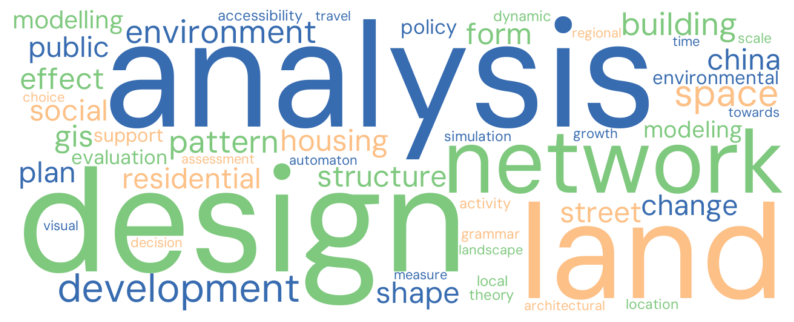

In [66]:
#from src.analysistools import __gen_cloud_3_color__
__gen_cloud_3_color__(full_freq[:50], 1280, 500)

# 2, Word Cloud for Each decade 
## 2.1 1970s 

In [14]:
from src.preprocessing import __decade_pre_process__

In [20]:
def __decade_pre_process__(data, stopword):
    #print(data.head())
    data['Title'] = data['Title'].astype(str)
    data['title_clean'] = __general_preprocess__(data['Title'])
    data['title_clean'] = __remove_punctuation__(data['title_clean'])
    data['title_clean'] = data['title_clean'].apply(lambda x: __remove_plurals__(x))
    data['title_clean'] = __remove_stopwords__(data['title_clean'], stopword)
    data_freq = __get_word_freq__(data['title_clean'])
    return data_freq#[:30]

In [21]:
df70_freq = __decade_pre_process__(df70, epb_stop_words)
df70_freq

design           20
architectural    10
rectangular      10
plan              9
theory            9
                 ..
minimal           1
grating           1
best              1
perspective       1
dimensional       1
Name: count, Length: 275, dtype: int64

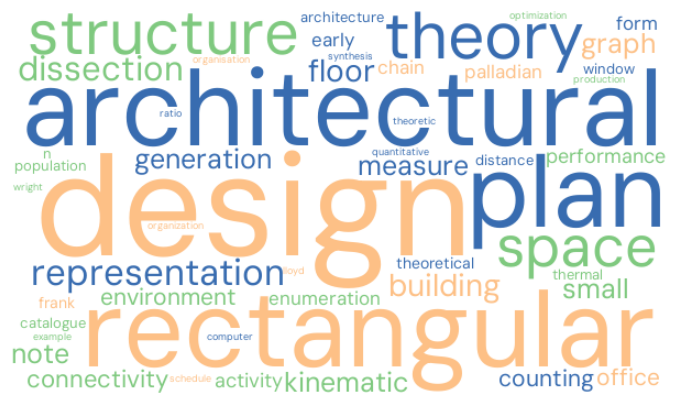

In [64]:
__gen_cloud_3_color__(df70_freq[:50], 600, 350)

## 2.2 1980s 

In [23]:
df80_freq = __decade_pre_process__(df80, epb_stop_words)
df80_freq

design         47
land           23
analysis       23
theory         19
plan           17
               ..
star            1
scientific      1
simplify        1
mathematics     1
relativism      1
Name: count, Length: 714, dtype: int64

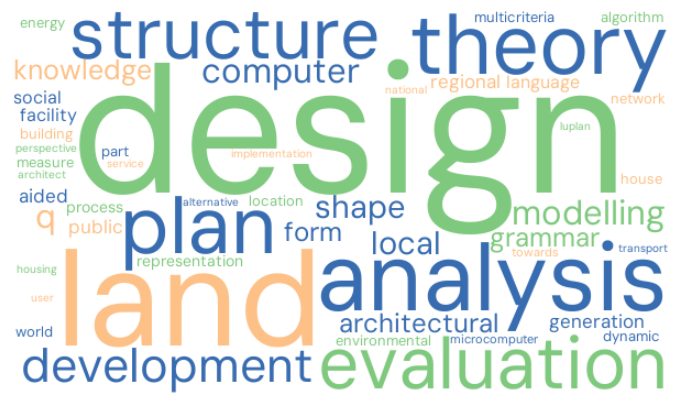

In [47]:
__gen_cloud_3_color__(df80_freq[:50], 600, 350)

## 2.3 1990s 

In [48]:
df90_freq = __decade_pre_process__(df90, epb_stop_words)
df90_freq

design          54
development     29
shape           28
land            23
analysis        20
                ..
trading          1
behaviour        1
accumulation     1
stratified       1
graph            1
Name: count, Length: 1002, dtype: int64

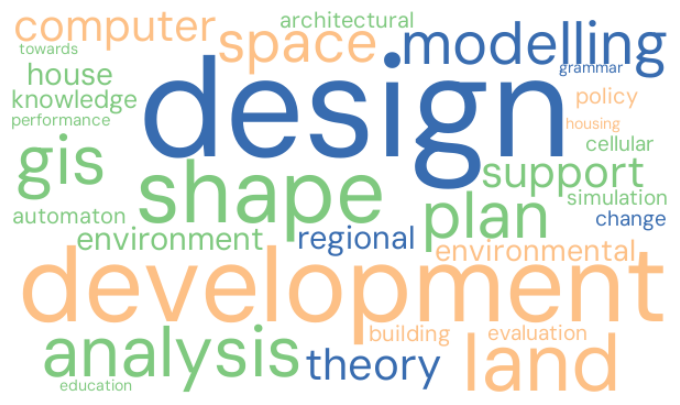

In [51]:
__gen_cloud_3_color__(df90_freq[:30], 600, 350)

## 2.4 2000s 

In [52]:
df00_freq = __decade_pre_process__(df00, epb_stop_words)
df00_freq

land           52
analysis       43
gis            43
design         36
development    31
               ..
rainforest      1
israeli         1
toll            1
stochastic      1
better          1
Name: count, Length: 1408, dtype: int64

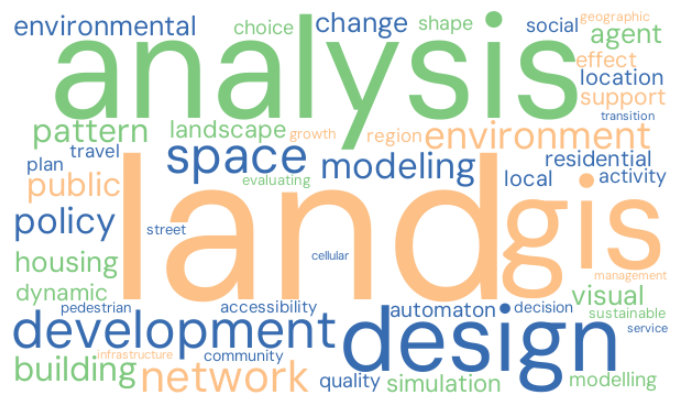

In [53]:
__gen_cloud_3_color__(df00_freq[:50],600,350)

## 2.5 2010s 

In [54]:
df10_freq = __decade_pre_process__(df10, epb_stop_words)
df10_freq

analysis       73
land           52
network        48
design         44
development    37
               ..
aspiration      1
emerging        1
plot            1
eastern         1
satellite       1
Name: count, Length: 1709, dtype: int64

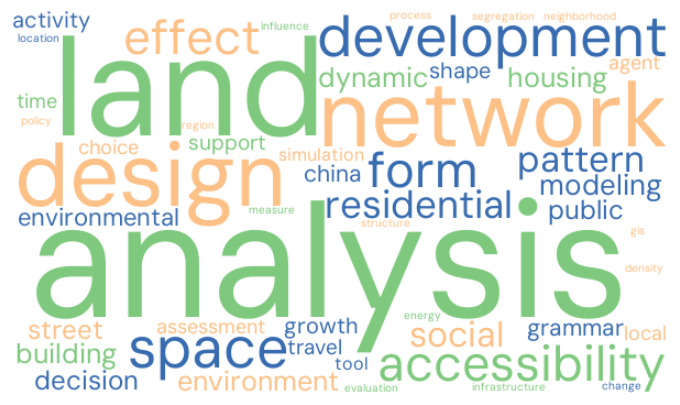

In [59]:
__gen_cloud_3_color__(df10_freq[:50],600,350)

## 2.6 2020s 

In [60]:
df20_freq = __decade_pre_process__(df20, epb_stop_words)
df20_freq

analysis     63
network      50
street       35
china        33
space        31
             ..
proposing     1
industry      1
bottom        1
dongguan      1
ridership     1
Name: count, Length: 1707, dtype: int64

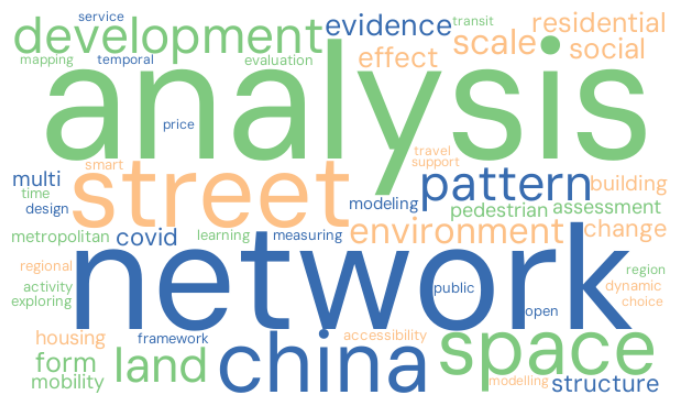

In [62]:
__gen_cloud_3_color__(df20_freq[:50], 600, 350)

## 3 AVG Author Per Decade

In [67]:
from src.analysistools import __count_authors__
from src.analysistools import __get_decade_author__

In [78]:
__get_decade_author__(df70)

AVG per decade: 1.3258426966292134


In [79]:
__get_decade_author__(df80)

AVG per decade: 1.4526315789473685


In [80]:
__get_decade_author__(df90)

AVG per decade: 1.7170731707317073


In [81]:
__get_decade_author__(df00)

AVG per decade: 2.201171875


In [82]:
__get_decade_author__(df10)

AVG per decade: 2.8363338788870704


In [83]:
__get_decade_author__(df20)

AVG per decade: 3.360861759425494
